GOAL: test the equations coupling and the variable timestep.

L'équation de dissolution d'un mineral traceur et de l'évolution des concentrations s'écrit:

$$
  \forall n \in [0, N], \left\{
    \begin{array}{l}
      V_{i} \omega_{e, i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{c_{j}^{n} - c_{i}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - V_{i} \omega_{e, i} \dfrac{\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}}{\Delta t^{n}}
      \\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

Note that this is strictly equivalent to :

$$
  \forall n \in [0, N], \left\{
    \begin{array}{l}
      c_{i}^{n+1} = c_{i}^{n} + \dfrac{\Delta t^{n}}{V_{i} \omega_{e, i}} \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{c_{j}^{n} - c_{i}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - \overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}
      \\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

However, the first system is more convinient because of the implicit scheme in the first equation. It is actually closer to the numerical implementation (in matrix form).

And the fixed point iteration criteria, $ \text{max} \left\lVert 1 - \dfrac{\overline{c}^{n+1, k+1}}{\overline{c}^{n+1, k}} \right\rVert  < \epsilon $, with $k$ the number of fixed point iterations.

$$ \mathcal{L} = \dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}^{n, \mathrm{obs}}}}\right)^{2} + \dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{\overline{c}_{i}^{n, \mathrm{obs}} - \overline{c}_{i}^{n, \mathrm{calc}}}{\sigma_{\overline{c}_{i}^{n, \mathrm{obs}}}}\right)^{2}- \langle \lambda_{c_{i}^{n+1}}, g_{c} \rangle - \langle \lambda_{\overline{c}_{i}^{n+1}}, g_{\overline{c}} \rangle $$

explicitly it reads:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}}^{n, \mathrm{obs}}}\right)^{2} + \dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{\overline{c}_{i}^{n, \mathrm{obs}} - \overline{c}_{i}^{n, \mathrm{calc}}}{\sigma_{\overline{c}_{i}}^{n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{n}\Bigg[V_{i} \omega_{e, i} \dfrac{c_{i}^{n+1} - c_{i}^{n}}{\Delta t^{n}} - \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{c_{j}^{n+1} - c_{i}^{n+1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{c_{j}^{n} - c_{i}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) + V_{i} \omega_{e, i} \dfrac{\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n}}{\Delta t^{n}} \Bigg]
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{n} \Bigg[\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} - \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
 \Bigg]  
\end{aligned}
\end{equation}

## 1) Derivation by $\overline{c}_{i}^{n}$:

$$
\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} =
\begin{cases}
    - \dfrac{\overline{c}_{i}^{0, \mathrm{obs}} - \overline{c}_{i}^{0, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{0} + \lambda_{\overline{c}_{i}}^{0} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{0}}{K_{s}}\right) \right) , & \text{if}\ n = 0 
    \\\\
    - \dfrac{\overline{c}_{i}^{n, \mathrm{obs}} - \overline{c}_{i}^{n, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{n, \mathrm{obs}}\right)^{2}} + V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}} - \dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}}\right) + \lambda_{\overline{c}_{i}}^{n} - \lambda_{\overline{c}_{i}}^{n-1} + \lambda_{\overline{c}_{i}}^{n} \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) , & \forall n \in [1, N] 
    \\\\
    - \dfrac{\overline{c}_{i}^{N+1, \mathrm{obs}} - \overline{c}_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{\overline{c}_{i}}^{N} - \dfrac{V_{i} \omega_{e, i}}{\Delta t^{N}}  \lambda_{c_{i}}^{N}, & \text{if}\ n = N+1
\end{cases}
$$

Since we want to impose $\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} = 0$, it gives the initial condition for the adjoint state:

$$ \lambda_{\overline{c}_{i}}^{N} =  - \dfrac{V_{i} \omega_{e, i}}{\Delta t^{N}} \lambda_{c_{i}}^{N} - \dfrac{\overline{c}_{i}^{N+1, \mathrm{obs}} - \overline{c}_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{N+1, \mathrm{obs}}\right)^{2}}$$

And the temporal evolution, $V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}}\right)$ being an "adjoint transport" error source term:

$$\lambda_{\overline{c}_{i}}^{n-1} = \lambda_{\overline{c}_{i}}^{n} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}}\right) - \dfrac{\overline{c}_{i}^{n, \mathrm{obs}} - \overline{c}_{i}^{n, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{n, \mathrm{obs}}\right)^{2}}, \forall n \in [1, N] $$


## 2) Derivation by $c_{i}^{n}$:

$$
\dfrac{\partial \mathcal{L}}{\partial c_{i}^{n}} =
\begin{cases}
    - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{0} + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij} (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{0} - \lambda_{c_{i}}^{0}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}, & \text{if}\ n = 0 
    \\\\
    - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}} + V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}} - \dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}}\right) + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{\lambda_{c_{j}}^{n-1} - \lambda_{c_{i}}^{n-1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - \lambda_{\overline{c}_{i}}^{n-1} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} , & \forall n \in [1, N] 
    \\\\
    - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{c_{i}}^{N} \dfrac{V_{i} \omega_{e, i}}{\Delta t^{N}} + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \Bigg(\alpha_{\mathrm{d}} D_{e, ij}\dfrac{\lambda_{c_{j}}^{N} - \lambda_{c_{i}}^{N}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - \lambda_{\overline{c}_{i}}^{N} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}, & \text{if}\ n = N+1
\end{cases}
$$

In addition to the gradient on the initial mobile concentration, we obtain the initial condition on the adjoint variable:

$$ V_{i} \omega_{e, i} \dfrac{\lambda_{c_{i}}^{N}}{\Delta t^{N}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(\alpha_{\mathrm{d}}D_{e, ij}\dfrac{\lambda_{c_{j}}^{N} - \lambda_{c_{i}}^{N}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\big) - \lambda_{\overline{c}_{i}}^{N} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks} - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}}$$

- And the temporal evolution

$$ V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}}\right) = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{\lambda_{c_{j}}^{n-1} - \lambda_{c_{i}}^{n-1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - \lambda_{\overline{c}_{i}}^{n-1} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, \forall n \in [1, N]$$

## Summary

And the fixed point iteration criteria, $ \text{max} \left\lVert 1 - \dfrac{\lambda_{\overline{c}_{**}}^{n}}{\lambda_{\overline{c}_{*}}^{n}} \right\rVert  < \epsilon $, with $\lambda_{{c, **}}^{n}$ and $\lambda_{c, *}^{n}$ the mobile adjoint concentrations at the last and before last adjoint fixed point iterations.


$$
\begin{cases}
    V_{i} \omega_{e, i} \dfrac{\lambda_{c_{i}}^{N}}{\Delta t^{N}} = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert \big(\alpha_{\mathrm{d}}D_{e, ij}\dfrac{\lambda_{c_{j}}^{N} - \lambda_{c_{i}}^{N}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\big) - \lambda_{\overline{c}_{i}}^{N} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks} - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{N} =  - \dfrac{V_{i} \omega_{e, i}}{\Delta t^{N}} \lambda_{c_{i}}^{N} - \dfrac{\overline{c}_{i}^{N+1, \mathrm{obs}} - \overline{c}_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{N+1, \mathrm{obs}}\right)^{2}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{n-1} = \lambda_{\overline{c}_{i}}^{n} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}}\right), & \forall n \in [1, N]
    \\\\
    V_{i} \omega_{e, i} \left(\dfrac{\lambda_{c_{i}}^{n-1}}{\Delta t^{n-1}} - \dfrac{\lambda_{c_{i}}^{n}}{\Delta t^{n}}\right) = \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij}\Bigg(\alpha_{\mathrm{d}}\dfrac{\lambda_{c_{j}}^{n-1} - \lambda_{c_{i}}^{n-1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} + (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{n} - \lambda_{c_{i}}^{n}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}\Bigg) - \lambda_{\overline{c}_{i}}^{n-1} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, & \forall n \in [1, N] 
\end{cases}
$$

The gradients with respect to the initial immobile and mobile concentrations read:

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{0} + \lambda_{\overline{c}_{i}}^{0} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right)$$

and

$$\dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} = - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{0} + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij} (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{0} - \lambda_{c_{i}}^{0}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert}$$

## Numerical tests

In [1]:
import sys
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt

import numdifftools as nd
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
from pyrtid.forward.models import (
    TransportModel,
    get_owner_neigh_indices,
    TransportParameters,
    GeochemicalParameters,
    Geometry,
    TimeParameters,
)
from pyrtid.inverse.adjoint.amodels import AdjointTransportModel
from pyrtid.utils import (
    harmonic_mean,
    dxi_harmonic_mean,
    get_super_lu_preconditioner,
    NDArrayFloat,
)
from scipy.sparse import csc_array, lil_array, lil_matrix
from scipy.sparse.linalg import gmres
from pyrtid.utils.finite_differences import finite_gradient
import logging

In [2]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test


In [3]:
VERY_SMALL_NUMBER = 1e-20


def get_max_coupling_error(current_arr, prev_arr) -> float:
    num = np.where(
        np.abs(current_arr) <= VERY_SMALL_NUMBER, VERY_SMALL_NUMBER, current_arr
    )
    den = np.where(np.abs(prev_arr) <= VERY_SMALL_NUMBER, VERY_SMALL_NUMBER, prev_arr)
    return float(
        np.nan_to_num(
            np.max(np.abs(1 - num / den)),
            nan=0.0,
        )
    )


get_max_coupling_error(np.ones((3)), np.ones((3)))
get_max_coupling_error(np.zeros((3)), np.zeros((3)))
get_max_coupling_error(np.ones((10)) * 1e-33, np.ones((10)) * 1e-35)
get_max_coupling_error(np.ones((10)) * 0, np.ones((10)) * 1e-20)

0.0

In [4]:
nx = 20  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 3.23  # voxel dimension along the x axis
dy = 2.59  # voxel dimension along the y axis
dz = 1.5

geom = dmfwd.Geometry(nx, ny, dx, dy, dz)

# variable timestep
time_params = dmfwd.TimeParameters(
    duration=50 * 6000,  # in seconds
    dt_min=1000.0,
    dt_init=6000.0,  # timestep in seconds
    dt_max=12000.0,
)

# Chemistry parameters
c0_ref = 0.0001  # general initial concentration [molal]
c0_est = 0.0002
M0 = 0.001  # mineral grade [mol/kg] -> kg of water
M1 = 0.0005  # mineral grade [mol/kg] -> kg of water
M1 = np.abs(0.001 * (0.5 + 0.5 * np.sin(np.arange(nx) / 2))).reshape(20, -1)

# To test with null mineral
# M0 = 0
# M1 = 0 * np.ones((nx, ny))

kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 5000  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]
diffusion = 1e-9
porosity = 0.23

gch_params_ref = dmfwd.GeochemicalParameters(c0_ref, M0, kv, As, Ks)

gch_params_est = dmfwd.GeochemicalParameters(c0_est, M1, kv, As, Ks)

tr_params = dmfwd.TransportParameters(
    diffusion=diffusion,
    porosity=porosity,
    is_numerical_acceleration=True,
    crank_nicolson_diffusion=0.5,
    fpi_eps=1e-10,
)

In [5]:
geom.mesh_area

8.3657

In [6]:
geom.mesh_volume

12.54855

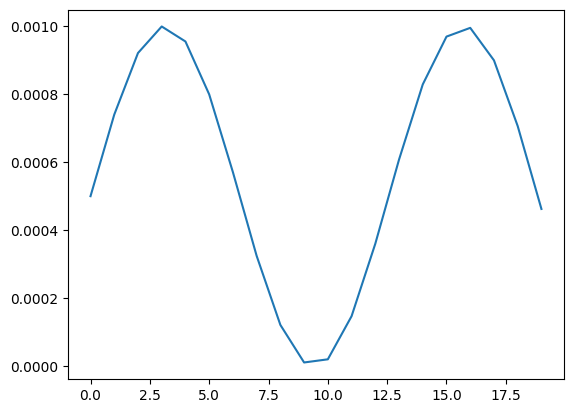

In [7]:
plt.plot(M1)

In [8]:
def make_transport_matrices_diffusion_only(
    geometry: dmfwd.Geometry,
    tr_model: TransportModel,
    time_params: dmfwd.TimeParameters,
) -> Tuple[lil_array, lil_array]:
    """
    Make matrices for the transport.

    Note
    ----
    Since the diffusion coefficient does not vary with time,
    matrices q_prev and q_next are the same.
    """
    dim = geometry.nx * geometry.ny
    q_prev = lil_array((dim, dim), dtype=np.float64)
    q_next = lil_array((dim, dim), dtype=np.float64)

    # X contribution
    if geometry.nx >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:-1, :] = harmonic_mean(
            tr_model.effective_diffusion[:-1, :], tr_model.effective_diffusion[1:, :]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = dmfwd.get_owner_neigh_indices(
            geometry,
            (slice(0, geometry.nx - 1), slice(None)),
            (slice(1, geometry.nx), slice(None)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        tmp = geometry.dy / geometry.dx / geometry.mesh_volume

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore

        # Backward scheme
        idc_owner, idc_neigh = dmfwd.get_owner_neigh_indices(
            geometry,
            (slice(1, geometry.nx), slice(None)),
            (slice(0, geometry.nx - 1), slice(None)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore

    # Y contribution
    if geometry.ny >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:, :-1] = harmonic_mean(
            tr_model.effective_diffusion[:, :-1], tr_model.effective_diffusion[:, 1:]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = dmfwd.get_owner_neigh_indices(
            geometry,
            (slice(None), slice(0, geometry.ny - 1)),
            (slice(None), slice(1, geometry.ny)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        tmp = geometry.dx / geometry.dy / geometry.mesh_volume

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore

        # Backward scheme
        idc_owner, idc_neigh = dmfwd.get_owner_neigh_indices(
            geometry,
            (slice(None), slice(1, geometry.ny)),
            (slice(None), slice(0, geometry.ny - 1)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore

    # Divide by dz to consider the volume
    return q_next, q_prev


def solve_transport(
    tr_model: TransportModel,
    geometry: Geometry,
    time_params: TimeParameters,
    time_index: int,
    nfpi: int,
) -> None:
    """
    Compute the transport problem.

    Parameters
    ----------
    tr_model: TransportModel
        The transport model.
    geometry: Geometry
        Geometry of the system.
    time_params: TimeParameters
        Time parameters of the system.
    time_index: int
        The iteration, or timestep id.
    nfpi:
        Number of fixed point iterations.
    """

    q_next: lil_matrix = tr_model.q_next_diffusion.copy()
    q_prev: lil_matrix = tr_model.q_prev_diffusion.copy()

    # Add 1/dt for the left term contribution
    q_next.setdiag(q_next.diagonal() + tr_model.porosity.flatten("F") / time_params.dt)
    q_prev.setdiag(q_prev.diagonal() + tr_model.porosity.flatten("F") / time_params.dt)

    # Multiply prev matrix by prev vector
    tmp = q_prev.dot(tr_model.lconc[time_index - 1].flatten(order="F"))

    # Chemical source term
    if tr_model.is_numerical_acceleration and nfpi == 1 and time_index != 1:
        dmdt = tr_model.lgrade[time_index - 1] - tr_model.lgrade[time_index - 2]
    else:
        dmdt = tr_model.lgrade[time_index] - tr_model.lgrade[time_index - 1]

    # The volume is included in the diffusion term
    tmp -= (dmdt * tr_model.porosity / time_params.dt).ravel(order="F")

    # Build the LU preconditioning
    preconditioner = get_super_lu_preconditioner(q_next.tocsc())

    # Solve Ax = b with A sparse using LU preconditioner
    res, exit_code = gmres(
        q_next.tocsc(), tmp, x0=None, M=preconditioner, atol=tr_model.tolerance
    )

    # In that regard, we save the intermediate concentrations for the non
    # iterative sequential apprach (adjoint state)
    tr_model.lconc[time_index] = res.reshape(geometry.ny, geometry.nx).T

    return exit_code


def solve_geochem(
    tr_model: TransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
) -> None:
    """Compute the geochemistry part."""

    # Need to take into account boundary conditions:
    # And then the reactive (chemistry) contribution with the updated conc

    # Note: the concentration has been modified by the transport so we need to use the
    # updated one.
    # m0 = tr_model.grade_post_tr[:, :, time_index]
    m0 = tr_model.lgrade[time_index - 1]

    # The mobile concentration is from the transport
    dMdt = (
        gch_params.kv
        * gch_params.As
        * m0
        * (1.0 - tr_model.lconc[time_index] / gch_params.Ks)
    )

    # overwrite the grade
    tr_model.lgrade[time_index] = m0 + dMdt * time_params.dt


def get_max_coupling_error(tr_model: TransportModel, time_index: int) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.nanmax(np.abs(1 - tr_model.lgrade[time_index] / tr_model.grade_prev)),
            nan=0.0,
        )
    )

In [9]:
tr_model_ref = TransportModel(geom, time_params, tr_params, gch_params_ref)
tr_model_ref.set_initial_grade(M0)
tr_model_est = TransportModel(geom, time_params, tr_params, gch_params_est)
tr_model_est.set_initial_grade(M1)

# Add boundary conditions
for tr_model in [tr_model_est, tr_model_ref]:
    tr_model.add_boundary_conditions(
        dmfwd.ConstantConcentration(span=(slice(0, 1), slice(None)))
    )
    tr_model.add_boundary_conditions(
        dmfwd.ConstantConcentration(span=(slice(nx - 1, nx), slice(None)))
    )


def solve_forward(
    _time_params: TimeParameters,
    _gch_params: GeochemicalParameters,
    _tr_model: TransportModel,
    geometry: Geometry,
    is_verbose: bool = False,
) -> None:
    _time_params.reset_to_init()

    # Initiate diffusion matrices
    (
        _tr_model.q_next_diffusion,
        _tr_model.q_prev_diffusion,
    ) = make_transport_matrices_diffusion_only(geometry, _tr_model, time_params)

    it = 0  # iteration

    # Otherwise there is an issue
    while time_params.time_elapsed < time_params.duration:
        it += 1
        nfpi = 1  # number of coupling (Fixed Point) iterations
        # Do not update the timestep for the first iteration
        # update the timestep based on the convergence speed.
        if it != 1:
            _time_params.update_dt(nfpi, 1e10)
        # Important: need to save the timestep after the update, otherwise, the
        # wrong timestep is used in the adjoint
        # Save the timesteps to the list of timesteps
        _time_params.save_dt()

        # Convergence flag
        has_converged = False

        # Copy the grades (To place in another function afterwards)
        _tr_model.lgrade.append(_tr_model.lgrade[it - 1])
        _tr_model.lconc.append(_tr_model.lconc[it - 1])

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            _tr_model.grade_prev = _tr_model.lgrade[it].copy()

            solve_transport(_tr_model, geometry, _time_params, it, nfpi)
            solve_geochem(_tr_model, _gch_params, time_params, it)

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nfpi}: {get_max_coupling_error(_tr_model, it)}"
                )
            has_converged = get_max_coupling_error(_tr_model, it) < _tr_model.fpi_eps
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nfpi += 1


solve_forward(time_params, gch_params_ref, tr_model_ref, geom, is_verbose=True)
solve_forward(time_params, gch_params_est, tr_model_est, geom)

max-coupling error at it = 1-1: 0.004703203194733385
has-converged ?: False
max-coupling error at it = 1-2: 4.185768885989205e-05
has-converged ?: False
max-coupling error at it = 1-3: 3.7075855141566194e-07
has-converged ?: False
max-coupling error at it = 1-4: 3.2841684927120696e-09
has-converged ?: False
max-coupling error at it = 1-5: 2.9090951869648052e-11
has-converged ?: True
max-coupling error at it = 2-1: 0.004713025390430725
has-converged ?: False
max-coupling error at it = 2-2: 2.645806198575684e-07
has-converged ?: False
max-coupling error at it = 2-3: 2.3793748082923116e-09
has-converged ?: False
max-coupling error at it = 2-4: 2.1397772442810492e-11
has-converged ?: True
max-coupling error at it = 3-1: 0.004763790132488621
has-converged ?: False
max-coupling error at it = 3-2: 2.633702973486862e-07
has-converged ?: False
max-coupling error at it = 3-3: 2.404474730433037e-09
has-converged ?: False
max-coupling error at it = 3-4: 2.195199577670337e-11
has-converged ?: True


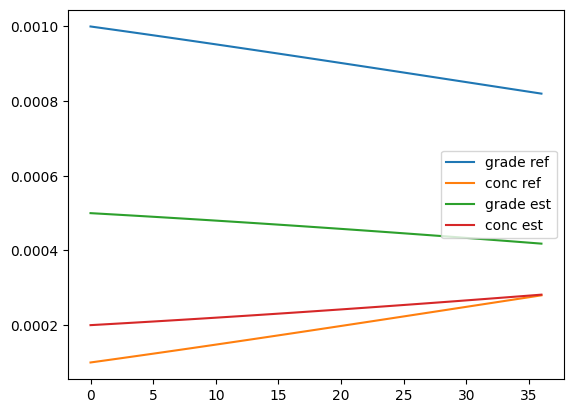

In [10]:
import matplotlib.pyplot as plt

plt.plot(tr_model_ref.grade[0, 0, :], label="grade ref")
plt.plot(tr_model_ref.conc[0, 0, :], label="conc ref")
plt.plot(tr_model_est.grade[0, 0, :], label="grade est")
plt.plot(tr_model_est.conc[0, 0, :], label="conc est")
plt.legend()

- Build an inverse

In [11]:
def solve_adjoint_geochem(
    tr_model: TransportModel,
    a_tr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    a_grade_sources: NDArrayFloat,
    time_index: int,
    nafpi: int,
) -> None:
    try:
        # Adjoint variables
        am_old = a_tr_model.a_grade[:, :, time_index + 1]
        ac_old = a_tr_model.a_conc[:, :, time_index + 1]
    except IndexError:
        am_old = 0
        ac_old = 0

    # Adjoint concentration at current timestep
    if (
        a_tr_model.is_adj_numerical_acceleration
        and nafpi == 1
        and time_index != time_params.nts
    ):
        ac_cur = a_tr_model.a_conc[:, :, time_index + 1]
    else:
        ac_cur = a_tr_model.a_conc[:, :, time_index]

    try:
        # Forward variables
        c_old = tr_model.lconc[time_index + 1]
        dt_cur = time_params.ldt[time_index]
    except IndexError:
        # for the first timestep, am_old = 0, so the following values do not matter
        c_old = 1.0
        dt_cur = 1.0
    dt_next = time_params.ldt[time_index - 1]

    # Update mineral value
    a_tr_model.a_grade[:, :, time_index] = (
        am_old
        * (1 + dt_cur * gch_params.kv * gch_params.As * (1.0 - c_old / gch_params.Ks))
        - (ac_cur / dt_next - ac_old / dt_cur) * tr_model.porosity * geom.mesh_volume
    ) + a_grade_sources[:, :, time_index]

    # Compute the adjoint geochem source term: it is computed here to mimic the
    # splitting operator approach in which the chemical parameters might not be
    # available in the transport operator - and consequently its adjoint.
    a_tr_model.a_gch_src_term = (
        a_tr_model.a_grade[:, :, time_index]
        * dt_next
        * gch_params.kv
        * gch_params.As
        * (tr_model.lgrade[time_index - 1] / gch_params.Ks)
    )


def make_adjoint_transport_matrices_diffusion_only(
    geometry: Geometry, tr_model: TransportModel, time_params: TimeParameters
) -> Tuple[lil_array, lil_array]:
    """
    Make matrices for the transient transport.

    Note
    ----
    Since the diffusion coefficient and porosity does not vary with time,
    matrices q_prev and q_next are the same.
    """

    dim = geometry.nx * geometry.ny
    q_prev = lil_array((dim, dim), dtype=np.float64)
    q_next = lil_array((dim, dim), dtype=np.float64)

    # X contribution
    if geometry.nx >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:-1, :] = harmonic_mean(
            tr_model.effective_diffusion[:-1, :], tr_model.effective_diffusion[1:, :]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(0, geometry.nx - 1), slice(None)),
            (slice(1, geometry.nx), slice(None)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        tmp = geometry.dy / geometry.dx / geometry.mesh_volume

        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore

        # Backward scheme
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(1, geometry.nx), slice(None)),
            (slice(0, geometry.nx - 1), slice(None)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore

    # Y contribution
    if geometry.ny >= 2:
        dmean: NDArrayFloat = np.zeros((geometry.nx, geometry.ny), dtype=np.float64)
        dmean[:, :-1] = harmonic_mean(
            tr_model.effective_diffusion[:, :-1], tr_model.effective_diffusion[:, 1:]
        )
        dmean = dmean.flatten(order="F")

        # Forward scheme:
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(None), slice(0, geometry.ny - 1)),
            (slice(None), slice(1, geometry.ny)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        tmp = geometry.dx / geometry.dy / geometry.mesh_volume

        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_owner] * tmp
        )  # type: ignore

        # Backward scheme
        idc_owner, idc_neigh = get_owner_neigh_indices(
            geometry,
            (slice(None), slice(1, geometry.ny)),
            (slice(None), slice(0, geometry.ny - 1)),
            owner_indices_to_keep=tr_model.free_conc_nn,
        )

        q_next[idc_owner, idc_neigh] -= (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_next[idc_owner, idc_owner] += (
            tr_model.crank_nicolson_diffusion * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_neigh] += (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore
        q_prev[idc_owner, idc_owner] -= (
            (1.0 - tr_model.crank_nicolson_diffusion) * dmean[idc_neigh] * tmp
        )  # type: ignore

    # divide by dz to take the volume into account
    return q_next, q_prev


def solve_adj_transport_transient_semi_implicit(
    geometry: Geometry,
    tr_model: TransportModel,
    a_tr_model: AdjointTransportModel,
    a_sources: NDArrayFloat,
    time_params: TimeParameters,
    time_index: int,
) -> int:
    """
    Solving the adjoint diffusivity equation:

    dc/dt = div D grad c + ...
    """

    crank_adv = tr_model.crank_nicolson_advection
    q_next = a_tr_model.q_next_diffusion.copy().tolil()
    q_prev = a_tr_model.q_prev_diffusion.copy().tolil()

    # Add 1/dt * \omgea for the left term contribution
    # Note; if the porosity and the timesteps are added here, it is to get the highest
    # values as possible on the diagonal of the matrices -> better conditionning
    # and easier LU preconditioning.
    q_next.setdiag(
        q_next.diagonal()
        + tr_model.porosity.flatten("F") / time_params.ldt[time_index - 1]
    )
    try:
        q_prev.setdiag(
            q_prev.diagonal()
            + tr_model.porosity.flatten("F") / time_params.ldt[time_index]
        )
        # Get the previous vector
        ac_old = a_tr_model.a_conc[:, :, time_index + 1].ravel("F")

        # Multiply prev matrix by prev vector
        tmp = q_prev.dot(ac_old)

    except IndexError:
        tmp = np.zeros(np.prod(geometry.shape))

    # Add the adjoint source terms
    tmp += (a_sources[:, :, time_index] / geometry.mesh_volume).ravel("F")

    # Add the adjoint geochem source term
    tmp -= (a_tr_model.a_gch_src_term / geometry.mesh_volume).ravel(
        "F"
    )  # / geometry.mesh_area / tr_model.porosity).ravel("F")

    # Build the LU preconditioning
    preconditioner = get_super_lu_preconditioner(q_next.tocsc())

    # Solve Ax = b with A sparse using LU preconditioner
    res, exit_code = gmres(q_next.tocsc(), tmp, M=preconditioner, atol=1e-15)
    # Note: we go backward in time, so time_index -1...
    a_tr_model.a_conc[:, :, time_index] = res.reshape(geometry.ny, geometry.nx).T

    return exit_code


def get_adjoint_max_coupling_error(
    a_tr_model: AdjointTransportModel, time_index: int
) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.max(
                np.abs(1 - a_tr_model.a_conc[:, :, time_index] / a_tr_model.a_conc_prev)
            ),
            nan=0.0,
        )
    )

In [12]:
time_params.ldt

[6000.0,
 6120.0,
 6242.400000000001,
 6367.2480000000005,
 6494.592960000001,
 6624.484819200001,
 6756.974515584001,
 6892.114005895681,
 7029.956286013595,
 7170.555411733867,
 7313.966519968544,
 7460.245850367915,
 7609.450767375274,
 7761.63978272278,
 7916.872578377236,
 8075.210029944781,
 8236.714230543677,
 8401.44851515455,
 8569.47748545764,
 8740.867035166793,
 8915.684375870129,
 9093.998063387531,
 9275.878024655281,
 9461.395585148388,
 9650.623496851356,
 9843.635966788384,
 10040.508686124153,
 10241.318859846635,
 10446.145237043567,
 10655.068141784439,
 10868.169504620128,
 11085.53289471253,
 11307.243552606782,
 11533.388423658918,
 11764.056192132097,
 11999.337315974739]

# Adjoint variable initialization

In [13]:
VERY_SMALL_NUMBER = 1e-30


def get_a_conc_sources(
    tr_model_ref: TransportModel, tr_model_est: TransportModel
) -> NDArrayFloat:
    _out = tr_model_ref.conc - tr_model_est.conc
    return -_out


def get_a_grade_sources(
    tr_model_ref: TransportModel, tr_model_est: TransportModel
) -> NDArrayFloat:
    _out = tr_model_ref.grade - tr_model_est.grade
    return -_out


def solve_adjoint_system(
    time_params: TimeParameters,
    gch_params: GeochemicalParameters,
    tr_model: TransportModel,
    geometry: Geometry,
    is_verbose: bool = False,
    afpi_eps: float = 1e-5,
    is_numerical_acceleration: bool = False,
) -> AdjointTransportModel:
    # Build an adjoint model
    a_tr_model = AdjointTransportModel(
        geometry,
        time_params,
        afpi_eps=afpi_eps,
        is_adj_numerical_acceleration=is_numerical_acceleration,
    )

    # Add the adjoint sources
    a_conc_sources = get_a_conc_sources(tr_model_ref, tr_model_est)
    a_grade_sources = get_a_grade_sources(tr_model_ref, tr_model_est)

    # Initiate diffusion matrices
    (
        a_tr_model.q_next_diffusion,
        a_tr_model.q_prev_diffusion,
    ) = make_adjoint_transport_matrices_diffusion_only(geometry, tr_model, time_params)

    # Otherwise there is an issue
    for it in range(time_params.nts, -1, -1):
        nafpi = 1  # number of coupling (Fixed Point) iterations
        # Convergence flag for the adjoint
        has_converged = False

        a_tr_model.a_conc[:, :, it] = VERY_SMALL_NUMBER

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            a_tr_model.a_conc_prev = a_tr_model.a_conc[:, :, it].copy()

            solve_adjoint_geochem(
                tr_model,
                a_tr_model,
                gch_params,
                time_params,
                a_grade_sources,
                it,
                nafpi,
            )

            # print(a_tr_model.a_grade[:, :, it])
            # print(a_tr_model.a_conc_prev)

            solve_adj_transport_transient_semi_implicit(
                geometry, tr_model, a_tr_model, a_conc_sources, time_params, it
            )

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nafpi}: {get_adjoint_max_coupling_error(a_tr_model, it)}"
                )
            has_converged = (
                get_adjoint_max_coupling_error(a_tr_model, it) < a_tr_model.afpi_eps
            )
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nafpi += 1
    return a_tr_model


a_tr_model = solve_adjoint_system(
    time_params,
    gch_params_est,
    tr_model_est,
    geom,
    is_verbose=True,
    is_numerical_acceleration=True,
    afpi_eps=1e-10,
)

max-coupling error at it = 36-1: 3.2419802451322505e+29
has-converged ?: False
max-coupling error at it = 36-2: 0.015145398763564133
has-converged ?: False
max-coupling error at it = 36-3: 0.00023291061891073106
has-converged ?: False
max-coupling error at it = 36-4: 3.5267025253471473e-06
has-converged ?: False
max-coupling error at it = 36-5: 5.341349829102171e-08
has-converged ?: False
max-coupling error at it = 36-6: 8.089686698298237e-10
has-converged ?: False
max-coupling error at it = 36-7: 1.2252421299763228e-11
has-converged ?: True
max-coupling error at it = 35-1: 6.154736883986003e+29
has-converged ?: False
max-coupling error at it = 35-2: 0.007383651495898258
has-converged ?: False
max-coupling error at it = 35-3: 0.000111004773968304
has-converged ?: False
max-coupling error at it = 35-4: 1.6563241189704314e-06
has-converged ?: False
max-coupling error at it = 35-5: 2.4717122570905303e-08
has-converged ?: False
max-coupling error at it = 35-6: 3.6884995058272807e-10
has-co

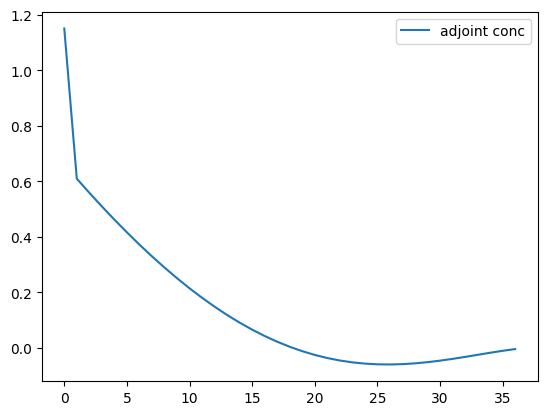

In [14]:
plt.plot(a_tr_model.a_conc[0, 0, :], label="adjoint conc")
plt.legend()

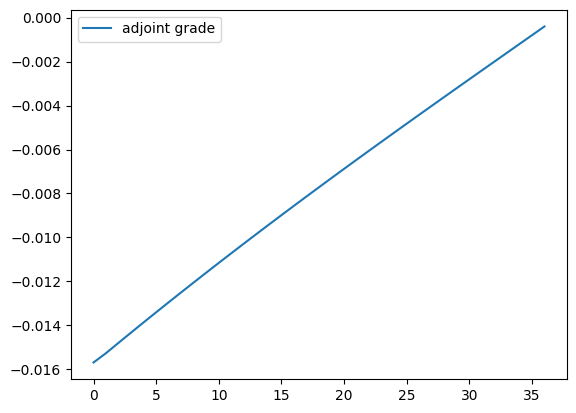

In [15]:
plt.plot(a_tr_model.a_grade[0, 0, :], label="adjoint grade")
plt.legend()

# Gradient computation

The gradients with respect to the initial immobile and mobile concentrations reads:

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right) - \dfrac{\overline{c}_{i}^{0, \mathrm{obs}} - \overline{c}_{i}^{0, \mathrm{calc}}}{\left(\sigma_{\overline{c}_{i}}^{0, \mathrm{obs}}\right)^{2}}$$

In [16]:
gch_params = gch_params_est


def get_init_mineral_gradient(time_params: TimeParameters):
    a_grade_sources = get_a_grade_sources(tr_model_ref, tr_model_est)
    return (
        a_tr_model.a_conc[:, :, 1]
        / time_params.ldt[0]
        * tr_model_est.porosity
        * geom.mesh_volume
        + a_tr_model.a_grade[:, :, 1]
        * (
            1
            + time_params.ldt[0]
            * gch_params.kv
            * gch_params.As
            * (1.0 - tr_model_est.conc[:, :, 1] / gch_params.Ks)
        )
        + a_grade_sources[:, :, 0]
    )


adjoint_init_min_gradient = get_init_mineral_gradient(time_params=time_params).ravel()
adjoint_init_min_gradient

array([-0.01541372, -0.00772801, -0.00186127,  0.00068286, -0.00075644,
       -0.00580471, -0.0131616 , -0.02097358, -0.02733784, -0.03076427,
       -0.03047638, -0.02653866, -0.01984692, -0.0119772 , -0.00485726,
       -0.00028837,  0.00054995, -0.00256051, -0.00881285, -0.0166095 ])

$$\dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} = - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \dfrac{V_{i} \omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{1} + \sum_{neigh \;j} \left\lVert \Gamma_{ij} \right\rVert D_{e, ij} (1 - \alpha_{\mathrm{d}})\dfrac{\lambda_{c_{j}}^{1} - \lambda_{c_{i}}^{1}}{ \left\lVert \overrightarrow{\mathrm{P}_{i}\mathrm{P}_{j}} \right\rVert} $$

In [17]:
gch_params = gch_params_est


def get_initial_conc_adjoint_gradient(time_params: TimeParameters) -> NDArrayFloat:
    r"""
    Gradient with respect to aqueous phase initial concentrations.

    The gradient reads

    .. math::

        \dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} =
        \dfrac{V_{i}\omega_{e, i}}{\Delta t^{0}} \lambda_{c_{i}}^{1}
        - \dfrac{c_{i}^{0, \mathrm{obs}}
        - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}}

    Note
    ----
    Parameter span is not taken into account which means that the gradient is
    computed on the full domain (grid).
    """
    a_conc_sources = get_a_conc_sources(tr_model_ref, tr_model_est)

    tr_model = tr_model_ref
    geometry = geom

    grad = (
        a_conc_sources[:, :, 0]
        + a_tr_model.a_conc[:, :, 1]
        * geom.mesh_volume
        * tr_model_est.porosity
        / time_params.ldt[0]
    )

    crank_diff = tr_model.crank_nicolson_diffusion
    a_conc = a_tr_model.a_conc[:, :, 1]

    # X axis contribution
    if a_tr_model.a_conc.shape[0] > 1:
        dmean = harmonic_mean(
            tr_model.effective_diffusion[:-1, :], tr_model.effective_diffusion[1:, :]
        )
        tmp = geometry.dy / geometry.dx
        # Forward scheme
        grad[:-1, :] += (
            +(1.0 - crank_diff) * (a_conc[1:, :] - a_conc[:-1, :]) * dmean
        ) * tmp
        # Backward scheme
        grad[1:, :] += (
            +(1.0 - crank_diff) * (a_conc[:-1, :] - a_conc[1:, :]) * dmean
        ) * tmp

    # Y axis contribution
    if a_tr_model.a_conc.shape[1] > 1:
        dmean = harmonic_mean(
            tr_model.effective_diffusion[:, :-1], tr_model.effective_diffusion[:, 1:]
        )
        tmp = geometry.dx / geometry.dy
        # Forward scheme
        grad[:, :-1] += (
            +(1.0 - crank_diff) * (a_conc[:, 1:] - a_conc[:, :-1]) * dmean
        ) * tmp
        # Backward scheme
        grad[:, 1:] += (
            +(1.0 - crank_diff) * (a_conc[:, :-1] - a_conc[:, 1:]) * dmean
        ) * tmp

    return grad


adjoint_init_conc_gradient = get_initial_conc_adjoint_gradient(
    time_params=time_params
).ravel()
adjoint_init_conc_gradient

array([0.00039298, 0.00124959, 0.00224528, 0.00276316, 0.00246396,
       0.00154468, 0.00058891, 0.00011573, 0.00018107, 0.00039657,
       0.00037341, 0.00014938, 0.00014751, 0.00071059, 0.00170141,
       0.0025595 , 0.00273486, 0.00211187, 0.00109702, 0.00030819])

- Objective function definition

In [18]:
def objfun_init_min(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(geom, time_params, tr_params, gch_params_est)
    _tr_model.set_initial_grade(x.reshape(nx, ny, order="F"))
    solve_forward(time_params, gch_params_est, _tr_model, geom, is_verbose=False)

    _a_conc_sources = get_a_conc_sources(tr_model_ref, _tr_model)
    _a_grade_sources = get_a_grade_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_conc_sources**2)) + float(
        0.5 * np.sum(_a_grade_sources**2)
    )


def objfun_init_conc(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(geom, time_params, tr_params, gch_params_est)
    _tr_model.set_initial_conc(x.reshape(nx, ny, order="F"))
    solve_forward(time_params, gch_params_est, _tr_model, geom, is_verbose=False)

    _a_conc_sources = get_a_conc_sources(tr_model_ref, _tr_model)
    _a_grade_sources = get_a_grade_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_conc_sources**2)) + float(
        0.5 * np.sum(_a_grade_sources**2)
    )

- Evaluate the objective function for the initial guess

In [19]:
objfun_init_min(M1, time_params)

8.437097605137643e-05

In [20]:
objfun_init_conc(M1, time_params)

0.00017418251324293643

- Define a step for the finite differences

In [21]:
eps_init_grade = float(np.max(np.abs(M1))) * np.power(np.finfo(float).eps, 1 / 3)
eps_init_grade

6.047869955132452e-09

In [22]:
eps_init_conc = float(np.max(np.abs(tr_model_est.conc[:, :, 0]))) * np.power(
    np.finfo(float).eps, 1 / 3
)
eps_init_conc

1.2110908904786686e-09

- We check the gradients by finite differences (with pyrtid and numdifftools, it is supposed to give the same results, the main difference is that pyrtid supports parallel running.)

In [23]:
def objfun_wrapper_init_min(x: NDArrayFloat) -> float:
    return objfun_init_min(x, time_params)


def objfun_wrapper_init_conc(x: NDArrayFloat) -> float:
    return objfun_init_conc(x, time_params)


fd_init_min_gradient_numdifftools = nd.Gradient(
    objfun_wrapper_init_min, step=eps_init_grade
)(tr_model_est.grade[:, :, 0].ravel("F"))
fd_init_min_gradient_pyrtid = finite_gradient(
    tr_model_est.grade[:, :, 0].ravel("F"),
    objfun_init_min,
    fm_args=(time_params,),
    eps=eps_init_grade,
)

fd_init_conc_gradient_numdifftools = nd.Gradient(
    objfun_wrapper_init_conc, step=eps_init_conc
)(tr_model_est.conc[:, :, 0].ravel("F"))
fd_init_conc_gradient_pyrtid = finite_gradient(
    tr_model_est.conc[:, :, 0].ravel("F"),
    objfun_init_conc,
    fm_args=(time_params,),
    eps=eps_init_conc,
)

In [24]:
fd_init_conc_gradient_numdifftools = nd.Gradient(
    objfun_wrapper_init_conc, step=eps_init_conc
)(tr_model_est.conc[:, :, 0].ravel("F"))
fd_init_conc_gradient_pyrtid = finite_gradient(
    tr_model_est.conc[:, :, 0].ravel("F"),
    objfun_init_conc,
    fm_args=(time_params,),
    eps=eps_init_conc,
)

- Plot the gradients

In [25]:
adjoint_init_min_gradient / fd_init_min_gradient_pyrtid

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.00000001, 1.        , 1.        , 1.        , 1.        ])

In [26]:
adjoint_init_conc_gradient / fd_init_conc_gradient_pyrtid

array([1.00000001, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.99999999, 1.00000001, 1.        ,
       0.99999999, 1.00000004, 1.00000003, 0.99999999, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.00000002])

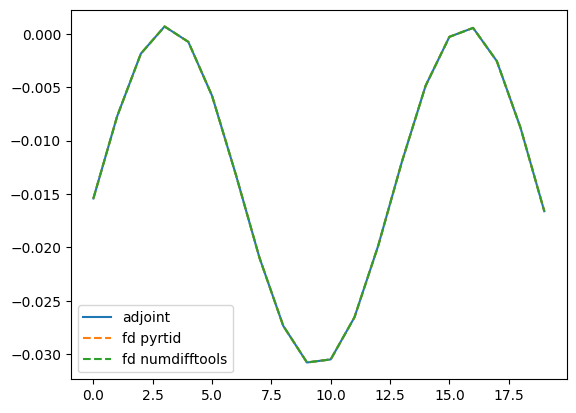

In [27]:
plt.plot(adjoint_init_min_gradient, label="adjoint")
plt.plot(fd_init_min_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_init_min_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

- Plot the residuals

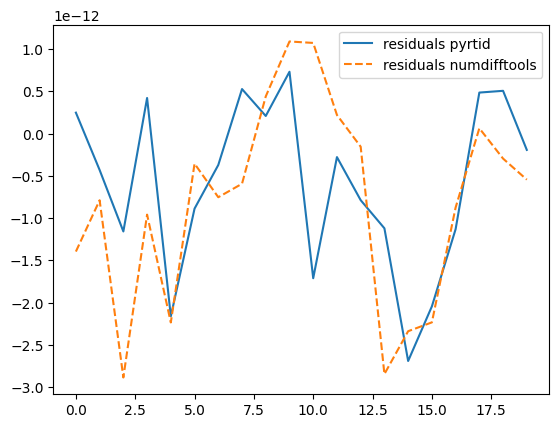

In [28]:
plt.plot(
    (adjoint_init_min_gradient - fd_init_min_gradient_pyrtid), label="residuals pyrtid"
)
plt.plot(
    (adjoint_init_min_gradient - fd_init_min_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()

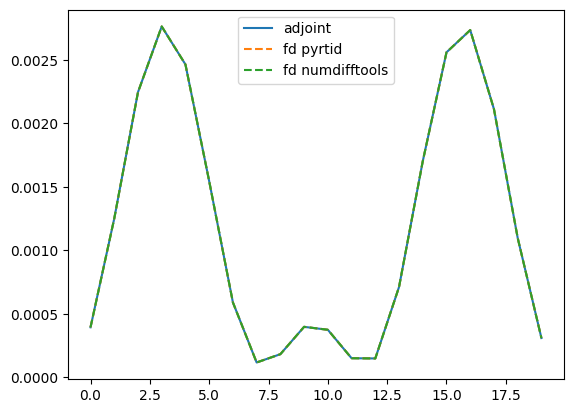

In [29]:
plt.plot(adjoint_init_conc_gradient, label="adjoint")
plt.plot(fd_init_conc_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_init_conc_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

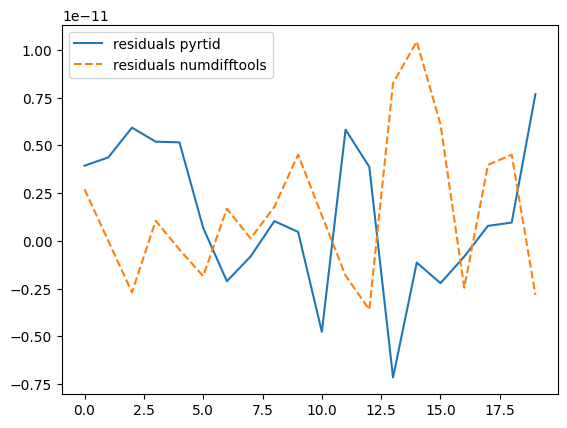

In [30]:
plt.plot(
    (adjoint_init_conc_gradient - fd_init_conc_gradient_pyrtid),
    label="residuals pyrtid",
)
plt.plot(
    (adjoint_init_conc_gradient - fd_init_conc_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()